In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from stats_ops import calculate_metrics
from analysis_utils import count_irrigated_hectares
from plots import make_line_plot_with_error, make_pumping_comparison_scatter_plot

%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT



PosixPath('/Users/mdfahimhasan/Documents/PROJECTS/westUS_pumping')

--------------------------------------

In [3]:
model_version = 'v11'   ###################

# Scatter plot comparison
`actual vs predicted pumping`

In [4]:
# GW-dominated
ml_df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

gw_dominated = ['gmd4', 'gmd3', 'rpb', 'slv', 'hqr', 'doug', 'scruz', 'dv']
ml_df = ml_df[ml_df['basin_code'].isin(gw_dominated)]
ml_df = ml_df.dropna()

error_dict = calculate_metrics(predictions=ml_df['mean pred_pumping_mm'], targets=ml_df['mean actual_pumping_mm'])
print('\nGW-dependent')
print('--------------')
print(f'Basins: {gw_dominated}')
print(f"\nNSE: {error_dict['R2']:.3f}")
print(f"RMSE: {error_dict['RMSE']:.3f} mm/year")
print(f"MAE: {error_dict['MAE']:.3f} mm/year")          

print(error_dict)


GW-dependent
--------------
Basins: ['gmd4', 'gmd3', 'rpb', 'slv', 'hqr', 'doug', 'scruz', 'dv']

NSE: 0.807
RMSE: 14.027 mm/year
MAE: 8.727 mm/year
{'RMSE': np.float64(14.026708355469648), 'MAE': np.float64(8.727254255379892), 'R2': np.float64(0.8069148576685687), 'Normalized RMSE': np.float64(0.3339962010131967), 'Normalized MAE': np.float64(0.20780853873221788), 'PBIAS': np.float64(-14.776201020487775)}


In [5]:
ml_df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

gw_dominated = ['gmd4', 'gmd3', 'rpb', 'slv', 'hqr', 'doug', 'scruz', 'dv']
ml_df = ml_df[ml_df['basin_code'].isin(gw_dominated)]
ml_df = ml_df.dropna()

mean_error_bias = np.sum(ml_df['mean actual_pumping_mm'] - ml_df['mean pred_pumping_mm']) / len(ml_df)

print(f'Basins: {gw_dominated}')
print(f'mean error (bias) = {mean_error_bias}')

Basins: ['gmd4', 'gmd3', 'rpb', 'slv', 'hqr', 'doug', 'scruz', 'dv']
mean error (bias) = -6.205503586191563


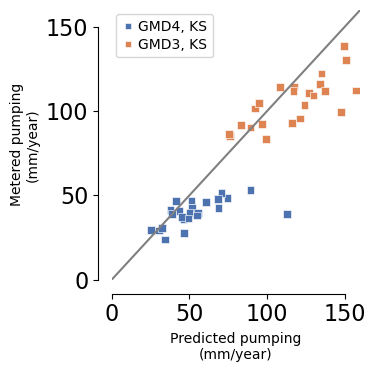

In [6]:
ml_df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

# dropping nan values (some basins has no actual pumping data for years)
ml_df = ml_df[['basin_code', 'mean pred_pumping_mm', 'mean actual_pumping_mm']]
ml_df = ml_df.dropna()

# naming basins
basin_name = {
        'gmd3': 'GMD3, KS',
        'gmd4': 'GMD4, KS',
    }

ml_df['basin'] = ml_df['basin_code'].map(basin_name)
ml_df = ml_df[ml_df['basin'].isin(list(basin_name.values()))]

save_path = None

# plotting
make_pumping_comparison_scatter_plot(df=ml_df, x='mean pred_pumping_mm', y='mean actual_pumping_mm', 
                                     hue='basin', xlabel='Predicted pumping\n(mm/year)', ylabel='Metered pumping\n(mm/year)', 
                                     fontsize=16, lim=(0, 160),
                                     scientific_ticks=False,
                                     figsize=(4, 4), savepath=save_path,
                                     legend='on', legend_font=10,
                                     inset_basins=None)

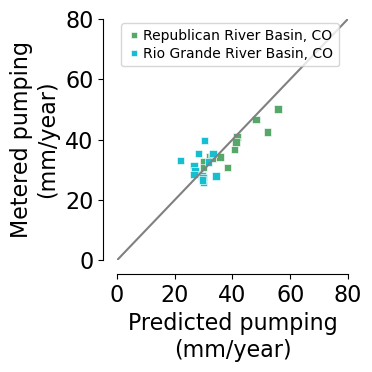

In [7]:
ml_df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

# dropping nan values (some basins has no actual pumping data for years)
ml_df = ml_df[['basin_code', 'mean pred_pumping_mm', 'mean actual_pumping_mm']]
ml_df = ml_df.dropna()

# naming basins
basin_name = {
        'rpb': 'Republican River Basin, CO',
        'slv': 'Rio Grande River Basin, CO'
    }

ml_df['basin'] = ml_df['basin_code'].map(basin_name)
ml_df = ml_df[ml_df['basin'].isin(list(basin_name.values()))]

save_path = None

# plotting
make_pumping_comparison_scatter_plot(df=ml_df, x='mean pred_pumping_mm', y='mean actual_pumping_mm', 
                                     hue='basin', xlabel='Predicted pumping\n(mm/year)', ylabel='Metered pumping\n(mm/year)', 
                                     fontsize=16, lim=(0, 80),
                                     scientific_ticks=False,
                                     figsize=(4, 4), savepath=save_path,
                                     legend='on', legend_font=10,
                                     inset_basins=None)


Basins in Arizona-Nevada
--------------
{'RMSE': np.float64(10.34320890948929), 'MAE': np.float64(6.048506671081942), 'R2': np.float64(0.6409675217518578), 'Normalized RMSE': np.float64(0.40944488074630914), 'Normalized MAE': np.float64(0.23943537390628641), 'PBIAS': np.float64(-16.12305244384475)}


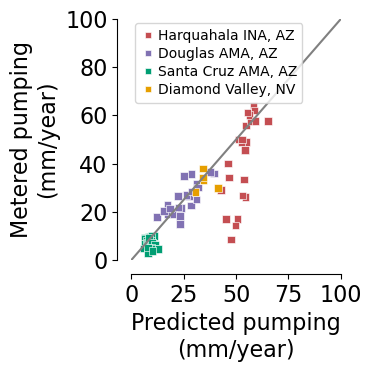

In [8]:
ml_df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

# dropping nan values (some basins has no actual pumping data for years)
ml_df = ml_df[['basin_code', 'mean pred_pumping_mm', 'mean actual_pumping_mm']]
ml_df = ml_df.dropna()

# naming basins
basin_name = {
        'hqr': 'Harquahala INA, AZ',
        'doug': 'Douglas AMA, AZ',
        'scruz': 'Santa Cruz AMA, AZ',
        'dv': 'Diamond Valley, NV'
    }

ml_df['basin'] = ml_df['basin_code'].map(basin_name)
ml_df = ml_df[ml_df['basin'].isin(list(basin_name.values()))]

save_path = None

# plotting
make_pumping_comparison_scatter_plot(df=ml_df, x='mean pred_pumping_mm', y='mean actual_pumping_mm', 
                                     hue='basin', xlabel='Predicted pumping\n(mm/year)', ylabel='Metered pumping\n(mm/year)', 
                                     fontsize=16, lim=(0, 100),
                                     scientific_ticks=False,
                                     figsize=(4, 4), savepath=save_path,
                                     legend='on', legend_font=10,
                                     inset_basins=None)

error_dict_ut = calculate_metrics(predictions=ml_df['mean pred_pumping_mm'], targets=ml_df['mean actual_pumping_mm'])

print(f'\nBasins in Arizona-Nevada')
print('--------------')
print(error_dict_ut)

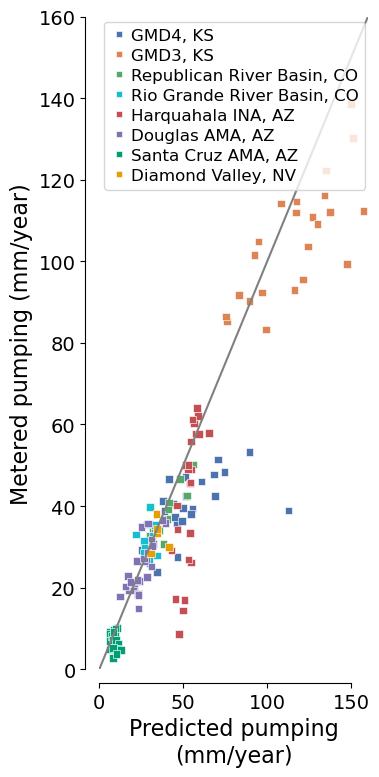

In [29]:
ml_df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

# dropping nan values (some basins has no actual pumping data for years)
ml_df = ml_df[['basin_code', 'mean pred_pumping_mm', 'mean actual_pumping_mm']]
ml_df = ml_df.dropna()

# naming basins
basin_name = {
        'gmd3': 'GMD3, KS',
        'gmd4': 'GMD4, KS',
        'rpb': 'Republican River Basin, CO',
        'slv': 'Rio Grande River Basin, CO',
        'hqr': 'Harquahala INA, AZ',
        'doug': 'Douglas AMA, AZ',
        'scruz': 'Santa Cruz AMA, AZ',
        'dv': 'Diamond Valley, NV'
    }

ml_df['basin'] = ml_df['basin_code'].map(basin_name)
ml_df = ml_df[ml_df['basin'].isin(list(basin_name.values()))]

save_path = PROJECT_ROOT / 'Model_run/plots/gw_dominated_scatter.png'

# plotting
make_pumping_comparison_scatter_plot(df=ml_df, x='mean pred_pumping_mm', y='mean actual_pumping_mm', 
                                     hue='basin', xlabel='Predicted pumping\n(mm/year)', ylabel='Metered pumping (mm/year)', 
                                     fontsize=14, lim=(0, 160),
                                     scientific_ticks=False,
                                     figsize=(4, 8), savepath=save_path,
                                     legend='on', legend_font=12,
                                     inset_basins=None)

---------------------

# Basin time series

In [10]:
# dataframe load for time series plot
lobo_ml = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_LOBO_{model_version}.csv')

df_ml = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

In [11]:
df_ml.columns

Index(['year', 'pred_pumping_m3', 'actual_pumping_m3', 'pred_pumping_AF',
       'actual_pumping_AF', 'mean pred_pumping_mm', 'mean actual_pumping_mm',
       'basin_code', 'basin', 'mean q025_mm', 'mean q975_mm'],
      dtype='object')

In [12]:
# UTAH basins
df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

ut_basin = ['pv', 'brl', 'cdr']
df_ut = df[df['basin_code'].isin(ut_basin)]
df_ut = df_ut.dropna()

error_dict_ut = calculate_metrics(predictions=df_ut['mean pred_pumping_mm'], targets=df_ut['mean actual_pumping_mm'])

print(f'\nBasins in Utah')
print('--------------')
print(error_dict_ut)


Basins in Utah
--------------
{'RMSE': np.float64(4.388064377594617), 'MAE': np.float64(3.304795139543344), 'R2': np.float64(0.19406579757973585), 'Normalized RMSE': np.float64(0.16823076452470143), 'Normalized MAE': np.float64(0.1267001039824435), 'PBIAS': np.float64(-6.089231132002206)}


# Kansas
-------------------

### GMD3

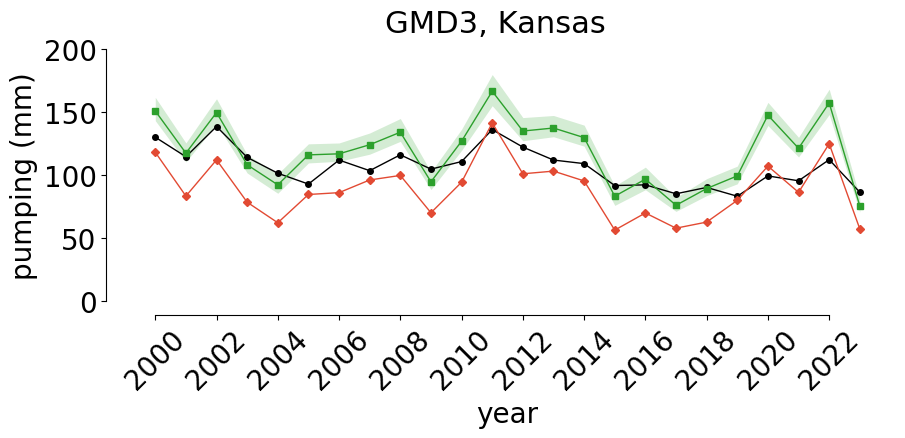

In [18]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'gmd3']
df_ml_sel = df_ml[df_ml['basin_code'] == 'gmd3']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual', 'predicted', 'LOBO'],   
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 200),
                          colors=None, markers=None, legend_pos='lower left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='GMD3, Kansas')

### GMD4

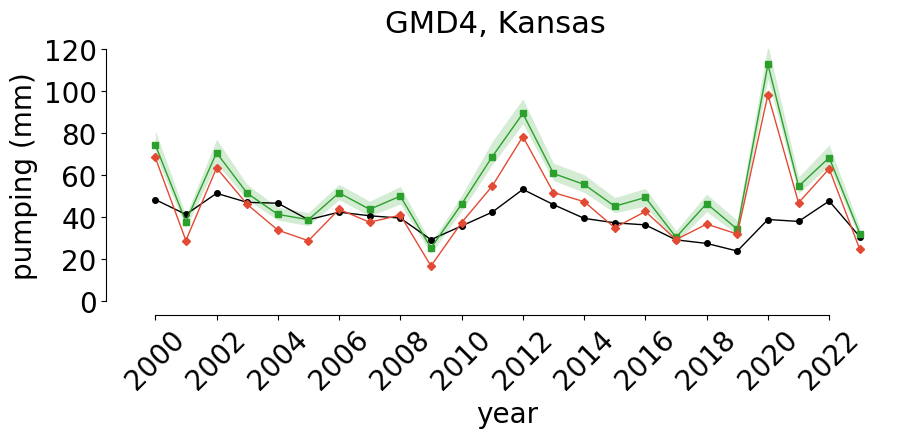

In [19]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'gmd4']
df_ml_sel = df_ml[df_ml['basin_code'] == 'gmd4']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual', 'predicted', 'LOBO'],   
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 120),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='GMD4, Kansas')

# Colorado
-----------------

### Republican Basin

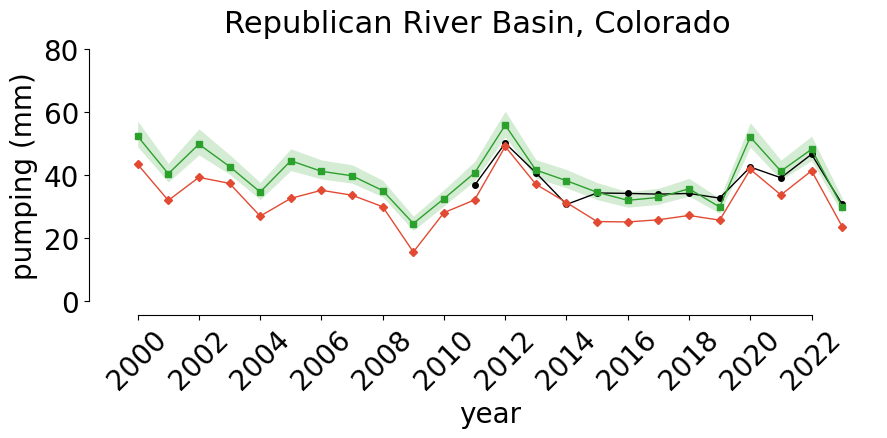

In [20]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'rpb']
df_ml_sel = df_ml[df_ml['basin_code'] == 'rpb']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual', 'predicted', 'LOBO'],    
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 80),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Republican River Basin, Colorado')

### Rio Grande Basin

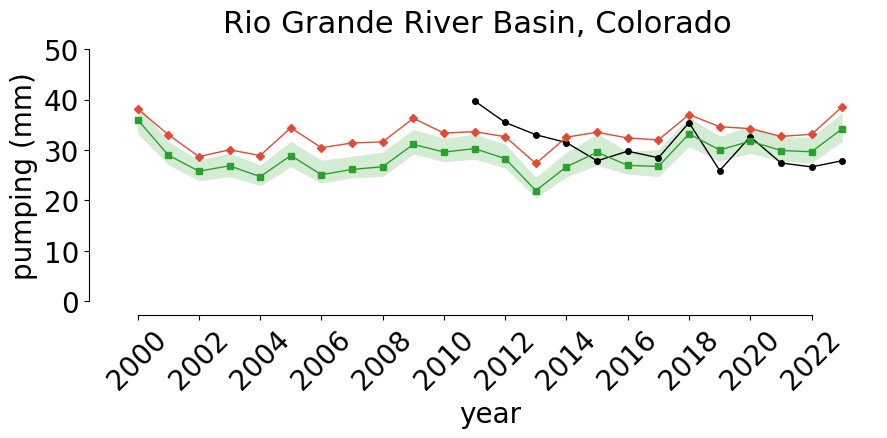

In [21]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'slv']
df_ml_sel = df_ml[df_ml['basin_code'] == 'slv']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual', 'predicted', 'LOBO'],   
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 50),
                          colors=None, markers=None, legend_pos='lower left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Rio Grande River Basin, Colorado')

# Arizona

### Harquahala INA

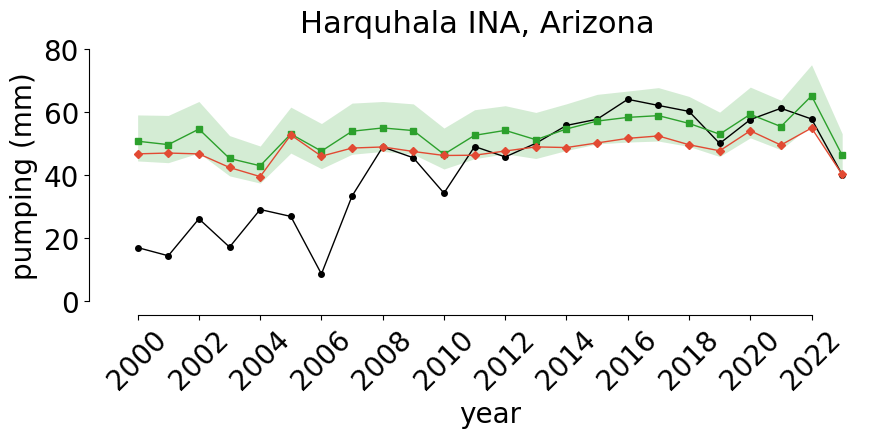

In [22]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'hqr']
df_ml_sel = df_ml[df_ml['basin_code'] == 'hqr']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual', 'predicted', 'LOBO'],     
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 80),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Harquhala INA, Arizona')

`Why is the huge gap between predicted and irrigation before 2008?`
- There were more surface water rights before 2008. Our model doesn't capture such management decisions.

`This version is with 1% irr_frac.`

### Douglas AMA

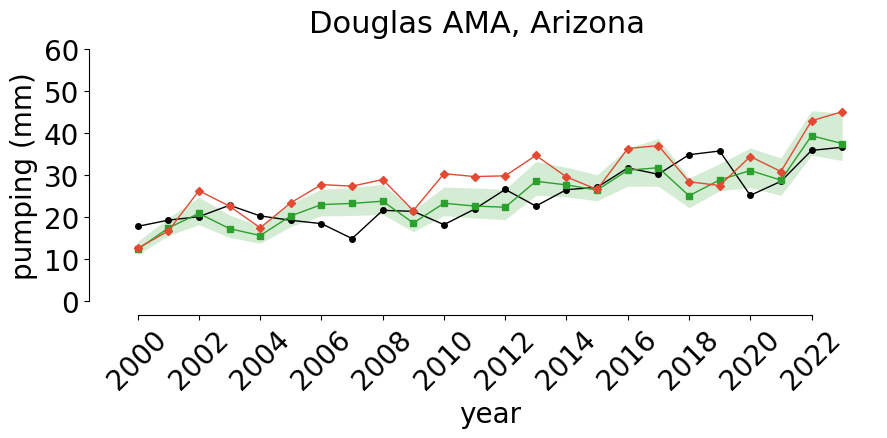

In [23]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'doug']
df_ml_sel = df_ml[df_ml['basin_code'] == 'doug']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['metered', 'predicted', 'Spatial holdout (LOBO)'],   
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 60),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Douglas AMA, Arizona')

### Santa Cruz AMA

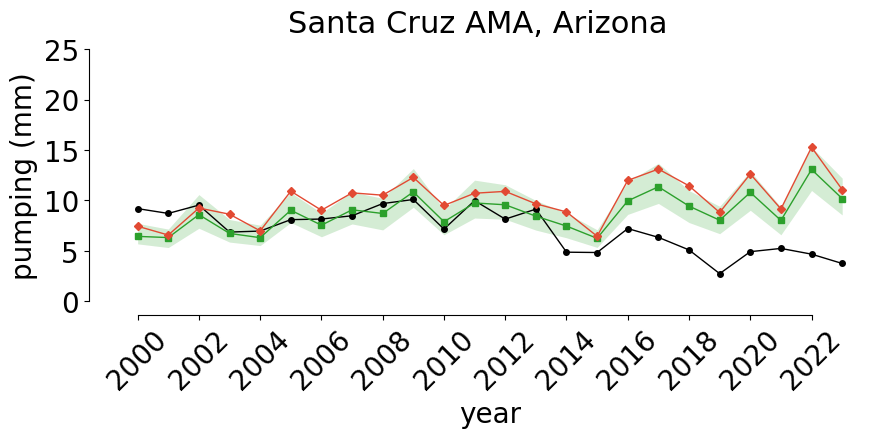

In [24]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'scruz']
df_ml_sel = df_ml[df_ml['basin_code'] == 'scruz']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual', 'predicted', 'LOBO'],    
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 25),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Santa Cruz AMA, Arizona')

# Nevada
-------------------------

### Diamond Valley

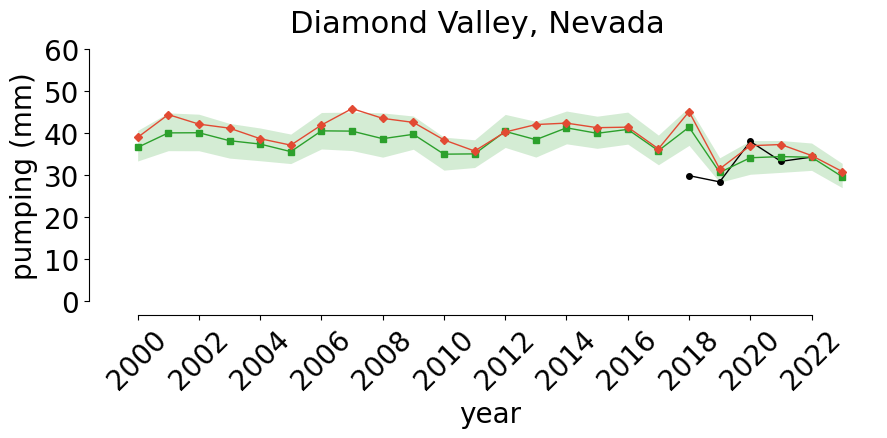

In [25]:
ml_lobo = lobo_ml[lobo_ml['basin_code'] == 'dv']
df_ml_sel = df_ml[df_ml['basin_code'] == 'dv']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                          ml_lobo['mean pred_pumping_mm']],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual', 'predicted', 'LOBO'],   
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 60),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Diamond Valley, Nevada')

# Utah
----------------------------

### Parowan Valley

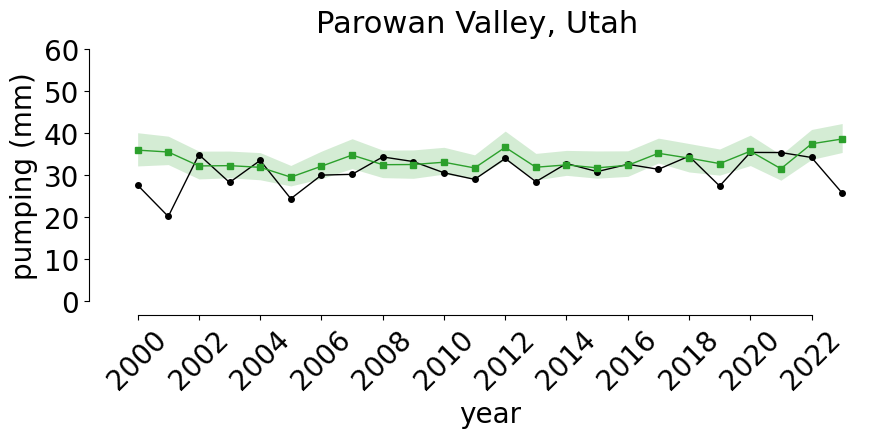

In [26]:
df_ml_sel = df_ml[df_ml['basin_code'] == 'pv']

save_path =  None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                                   ],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual\n(power consumption)', 
                                       'predicted'],   
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 60),
                          colors=None, markers=None, legend_pos='lower right',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Parowan Valley, Utah')

### Cedar Valley

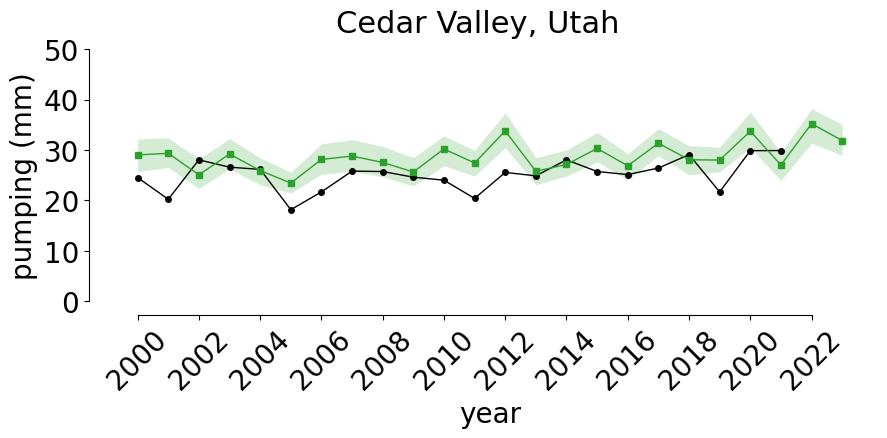

In [27]:
df_ml_sel = df_ml[df_ml['basin_code'] == 'cdr']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                                   ],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual\n(power consumption)', 
                                       'predicted'],   
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 50),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Cedar Valley, Utah')

### Beryl-Enterprise

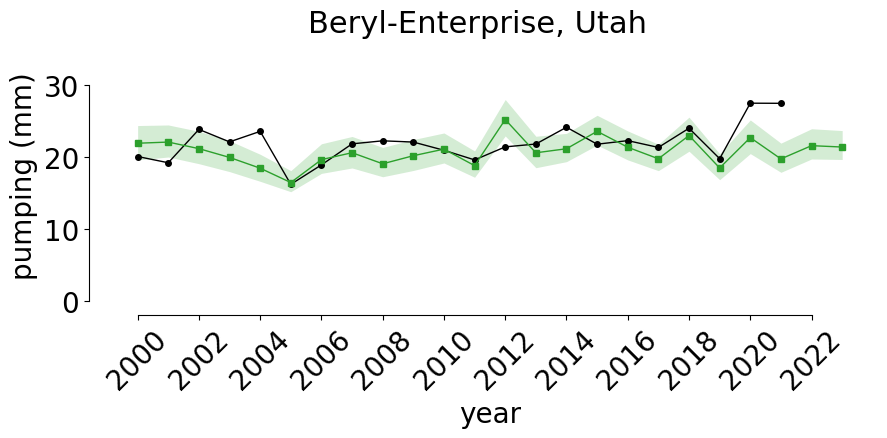

In [28]:
df_ml_sel = df_ml[df_ml['basin_code'] == 'brl']

save_path = None

# plot
make_line_plot_with_error(y_series=[df_ml_sel['mean actual_pumping_mm'],
                          df_ml_sel['mean pred_pumping_mm'],
                                   ],
                          year=df_ml_sel['year'], 
                          fontsize=20, xlabel='year', ylabel='pumping (mm)',
                          line_labels=['actual\n(power consumption)', 
                                       'predicted'],  
                          low_CI=[None, df_ml_sel['mean q025_mm'], None], 
                          high_CI=[None, df_ml_sel['mean q975_mm'], None],
                          savepath=save_path, 
                          figsize=(10, 4), y_lim=(0, 35),
                          colors=None, markers=None, legend_pos='upper left',
                          legend='off', no_xticks=False,
                          alpha_band=0.2, suptitle='Beryl-Enterprise, Utah')

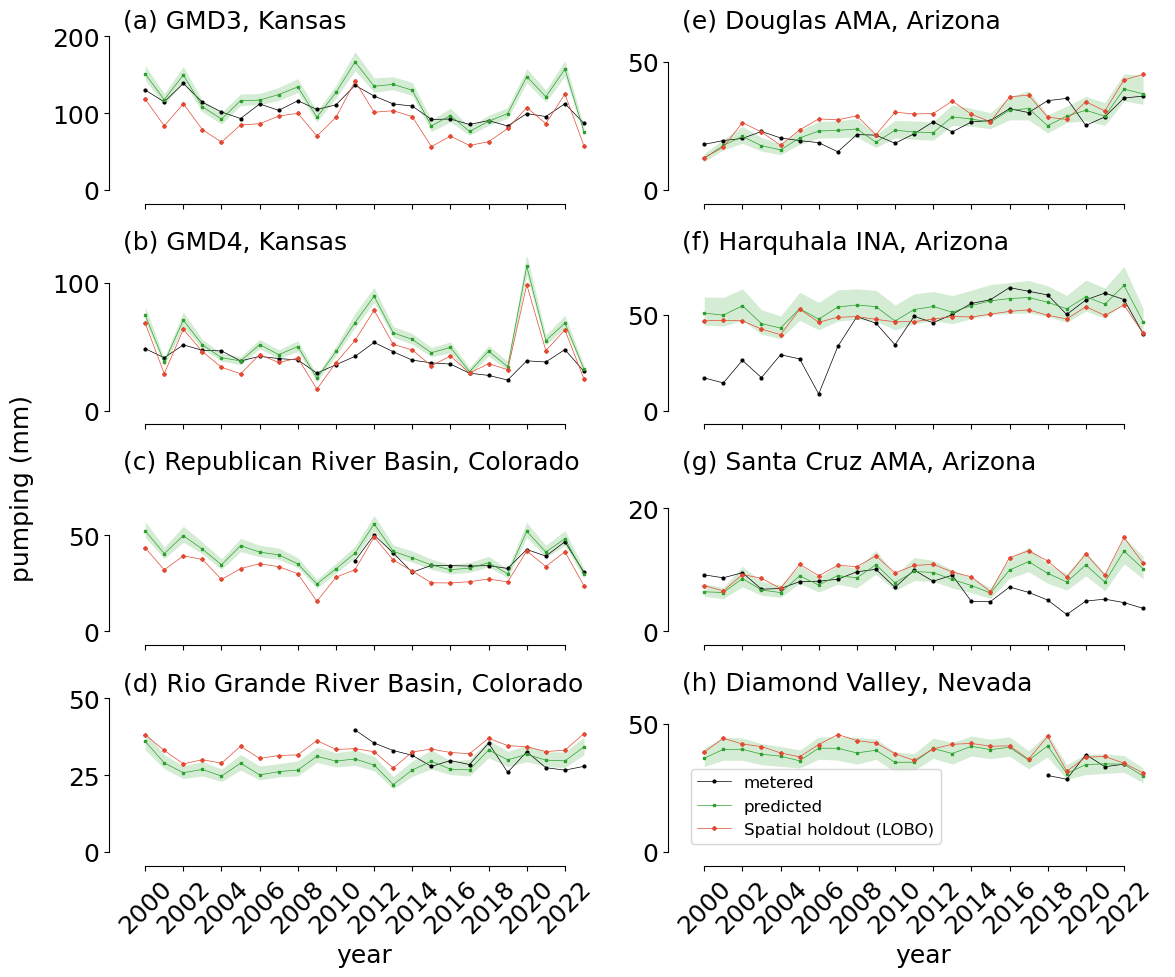

In [35]:
# Define basin configurations in exact panel order
basin_configs = [
    # (basin_code, y_lim, legend_pos, suptitle, panel_label, show_legend)
    ('gmd3',  (0, 200), 'lower left', 'GMD3, Kansas',                    '(a)', False),
    ('doug',  (0, 60),  'upper left', 'Douglas AMA, Arizona',             '(e)', False),
    ('gmd4',  (0, 120), 'upper left', 'GMD4, Kansas',                     '(b)', False),
    ('hqr',   (0, 80),  'upper left', 'Harquhala INA, Arizona',           '(f)', False),
    ('rpb',   (0, 80),  'upper left', 'Republican River Basin, Colorado', '(c)', False),
    ('scruz', (0, 25),  'upper left', 'Santa Cruz AMA, Arizona',          '(g)', False),
    ('slv',   (0, 50),  'lower left', 'Rio Grande River Basin, Colorado', '(d)', False),
    ('dv',    (0, 60),  'lower left', 'Diamond Valley, Nevada',           '(h)', True),
]

fontsize = 18

# Default colors/markers from your function
colors = [
    "#000000",  # black  - actual
    "#2ca02c",  # green  - predicted
    "#E24A33",  # red    - LOBO
]
markers = ['o', 's', 'D', '^', 'v', 'P', '*']
linestyles = ['-', '-', '-', '-.']

fig, axes = plt.subplots(4, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.35)

# Map to axes: left col = a,b,c,d | right col = e,f,g,h
ax_positions = [
    (0, 0),  # a - gmd3
    (0, 1),  # e - doug
    (1, 0),  # b - gmd4
    (1, 1),  # f - hqr
    (2, 0),  # c - rpb
    (2, 1),  # g - scruz
    (3, 0),  # d - slv
    (3, 1),  # h - dv
]

for idx, (basin_code, y_lim, legend_pos, suptitle, panel_label, show_legend) in enumerate(basin_configs):
    row, col = ax_positions[idx]
    ax = axes[row, col]

    # Filter data
    ml_lobo_sel = lobo_ml[lobo_ml['basin_code'] == basin_code]
    df_ml_sel   = df_ml[df_ml['basin_code'] == basin_code]

    year        = df_ml_sel['year']
    year_values = year.values

    # Define series, CI, labels
    actual_label = 'metered'
    lobo_label   = 'Spatial holdout (LOBO)'

    y_series  = [df_ml_sel['mean actual_pumping_mm'],
                 df_ml_sel['mean pred_pumping_mm'],
                 ml_lobo_sel['mean pred_pumping_mm']]
    low_CI    = [None, df_ml_sel['mean q025_mm'], None]
    high_CI   = [None, df_ml_sel['mean q975_mm'], None]
    line_labels = [actual_label, 'predicted', lobo_label]

    # Plot each series
    for i, y in enumerate(y_series):
        color = colors[i % len(colors)]
        ax.plot(year, y,
                label=line_labels[i],
                color=color,
                marker=markers[i],
                linestyle=linestyles[i],
                markersize=2,
                linewidth=0.5)

        if low_CI[i] is not None and high_CI[i] is not None:
            ax.fill_between(year,
                            low_CI[i],
                            high_CI[i],
                            color=color,
                            alpha=0.2,
                            linewidth=0)

    # Axis formatting
    ax.set_xticks(year_values[::2])
    ax.set_ylim(y_lim)
    ax.tick_params(axis='y', labelsize=fontsize)

    # Only last row gets x-label and x-tick labels
    if row == 3:
        ax.set_xticklabels(year_values[::2])
        ax.set_xlabel('year', fontsize=fontsize)
        ax.tick_params(axis='x', labelsize=fontsize, rotation=45)
    else:
        ax.set_xticklabels([])
        ax.set_xlabel('')

    # Title with panel label
    ax.set_title(f'{panel_label} {suptitle}', fontsize=fontsize, loc='left')

    # Legend only on last panel (h)
    if show_legend:
        ax.legend(loc=legend_pos, fontsize=fontsize-6)

    # Despine
    sns.despine(ax=ax, offset=10, trim=True)

# global y label
fig.supylabel('pumping (mm)', fontsize=fontsize)

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'Model_run/plots/TimeSeries_GW_dominanted.png',
    dpi=600, transparent=False, bbox_inches='tight'
)
plt.show()

In [30]:
# GW-dominated
ml_df = pd.read_csv(PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_{model_version}.csv')

utah_basins = ['pv', 'cdr', 'brl']
ml_df = ml_df[ml_df['basin_code'].isin(utah_basins)]
ml_df = ml_df.dropna()

error_dict = calculate_metrics(predictions=ml_df['mean pred_pumping_mm'], targets=ml_df['mean actual_pumping_mm'])
print('\nUtah basins')
print('--------------')
print(f"\nNSE: {error_dict['R2']:.3f}")
print(f"RMSE: {error_dict['RMSE']:.3f} mm/year")
print(f"MAE: {error_dict['MAE']:.3f} mm/year")          

print(error_dict)


Utah basins
--------------

NSE: 0.194
RMSE: 4.388 mm/year
MAE: 3.305 mm/year
{'RMSE': np.float64(4.388064377594617), 'MAE': np.float64(3.304795139543344), 'R2': np.float64(0.19406579757973585), 'Normalized RMSE': np.float64(0.16823076452470143), 'Normalized MAE': np.float64(0.1267001039824435), 'PBIAS': np.float64(-6.089231132002206)}


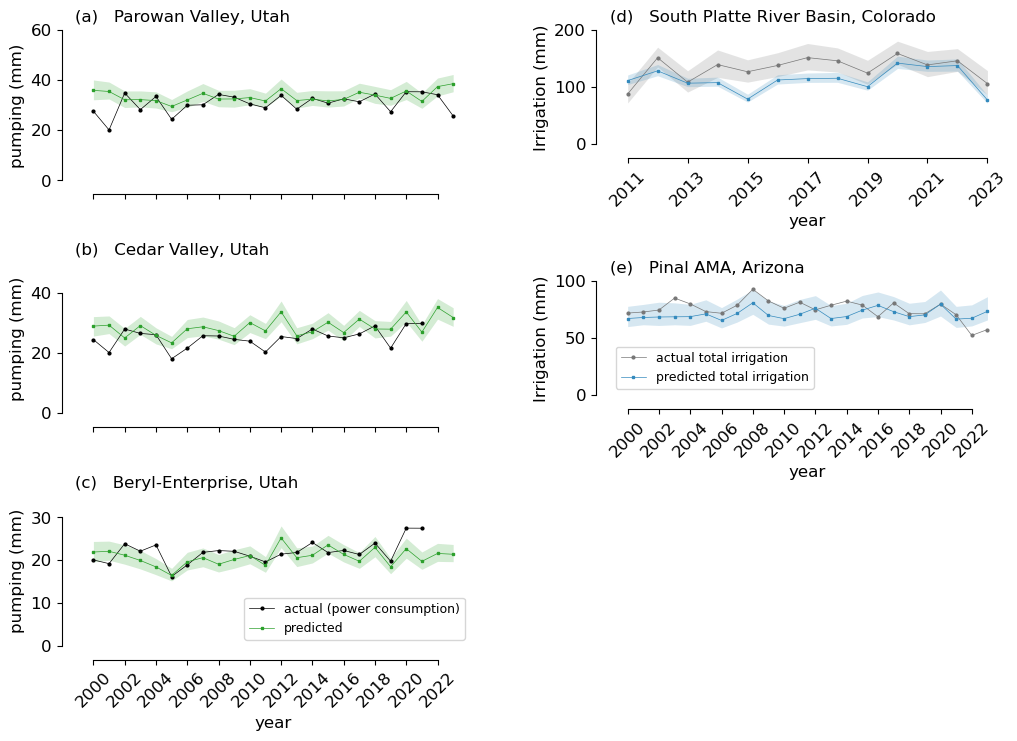

In [31]:
# ── Load data for South Platte and Pinal AMA ──────────────────────────────────
df_spb = pd.read_csv(PROJECT_ROOT / 'Model_run' / 'basin_comparison_results' / 'South_platte_total_Irr_balance.csv')

pnl_df = pd.read_csv(PROJECT_ROOT / 'Model_run' / 'basin_comparison_results' / 'Pinal_AMA_total_Irr_balance.csv')
pnl_df = pnl_df[['basin_code', 'year', 'predicted pumping_mm', 'mean q025_mm',
                  'mean q975_mm', 'total_Irr_mm (SW + GW)']]
pnl_df = pnl_df[(pnl_df['basin_code'] == 'pnl') & (pnl_df['year'].isin(range(2000, 2024)))]
df4    = pd.read_csv(PROJECT_ROOT / 'Data_main/pumping/Arizona/Final/SW_Pinal.csv')
df_pnl = pnl_df.merge(df4, on='year')

# ── Layout config ─────────────────────────────────────────────────────────────
fontsize    = 12
colors_gw   = ["#000000", "#2ca02c"]   # black, green
colors_conj = ["#777777", "#348ABD"]   # grey, blue
markers     = ['o', 's', 'D', '^']
linestyles  = ['-', '-']

# ── Helper to plot a single panel ─────────────────────────────────────────────
def plot_panel(ax, year, y_series, low_CI, high_CI, line_labels,
               colors, y_lim, ylabel, panel_label, suptitle,
               show_legend, legend_pos, show_xaxis, fontsize):

    year_values = year.values if hasattr(year, 'values') else year

    for i, y in enumerate(y_series):
        color = colors[i % len(colors)]
        ax.plot(year, y,
                label=line_labels[i],
                color=color,
                marker=markers[i],
                markersize=2,
                linewidth=0.5,
                linestyle=linestyles[i])

        if low_CI[i] is not None and high_CI[i] is not None:
            ax.fill_between(year,
                            low_CI[i],
                            high_CI[i],
                            color=color,
                            alpha=0.2,
                            linewidth=0)

    ax.set_ylim(y_lim)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xticks(year_values[::2])
    ax.tick_params(axis='y', labelsize=fontsize)

    if show_xaxis:
        ax.set_xticklabels(year_values[::2])
        ax.set_xlabel('year', fontsize=fontsize)
        ax.tick_params(axis='x', labelsize=fontsize, rotation=45)
    else:
        ax.set_xticklabels([])
        ax.set_xlabel('')

    ax.set_title(f'{panel_label}   {suptitle}', fontsize=fontsize, loc='left')

    if show_legend:
        ax.legend(loc=legend_pos, fontsize=fontsize - 3)

    sns.despine(ax=ax, offset=10, trim=True)


# ── Figure and gridspec ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 8))

# Main gridspec: 3 rows, 2 cols
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# Left column axes
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[2, 0])

# Right column: nested gridspec to control vertical spacing independently
gs_right = gridspec.GridSpecFromSubplotSpec(
    3, 1,
    subplot_spec=gs[:, 1],
    hspace=1.2          # increase to push (e) further down from (d)
)
ax_d = fig.add_subplot(gs_right[0])   # (d) - South Platte
ax_e = fig.add_subplot(gs_right[1])   # (e) - Pinal AMA
# gs_right[2] intentionally empty to align with (c) row


# ── Panel (a): Parowan Valley, Utah ──────────────────────────────────────────
df_pv = df_ml[df_ml['basin_code'] == 'pv']
plot_panel(ax=ax_a,
           year=df_pv['year'],
           y_series=[df_pv['mean actual_pumping_mm'], df_pv['mean pred_pumping_mm']],
           low_CI=[None, df_pv['mean q025_mm']],
           high_CI=[None, df_pv['mean q975_mm']],
           line_labels=['actual (power consumption)', 'predicted'],
           colors=colors_gw,
           y_lim=(0, 60), ylabel='pumping (mm)',
           panel_label='(a)', suptitle='Parowan Valley, Utah',
           show_legend=False, legend_pos='lower right',
           show_xaxis=False, fontsize=fontsize)

# ── Panel (b): Cedar Valley, Utah ────────────────────────────────────────────
df_cdr = df_ml[df_ml['basin_code'] == 'cdr']
plot_panel(ax=ax_b,
           year=df_cdr['year'],
           y_series=[df_cdr['mean actual_pumping_mm'], df_cdr['mean pred_pumping_mm']],
           low_CI=[None, df_cdr['mean q025_mm']],
           high_CI=[None, df_cdr['mean q975_mm']],
           line_labels=['actual (power consumption)', 'predicted'],
           colors=colors_gw,
           y_lim=(0, 50), ylabel='pumping (mm)',
           panel_label='(b)', suptitle='Cedar Valley, Utah',
           show_legend=False, legend_pos='upper left',
           show_xaxis=False, fontsize=fontsize)

# ── Panel (c): Beryl-Enterprise, Utah — show legend ──────────────────────────
df_brl = df_ml[df_ml['basin_code'] == 'brl']
plot_panel(ax=ax_c,
           year=df_brl['year'],
           y_series=[df_brl['mean actual_pumping_mm'], df_brl['mean pred_pumping_mm']],
           low_CI=[None, df_brl['mean q025_mm']],
           high_CI=[None, df_brl['mean q975_mm']],
           line_labels=['actual (power consumption)', 'predicted'],
           colors=colors_gw,
           y_lim=(0, 35), ylabel='pumping (mm)',
           panel_label='(c)', suptitle='Beryl-Enterprise, Utah',
           show_legend=True, legend_pos='lower right',
           show_xaxis=True, fontsize=fontsize)

# ── Panel (d): South Platte River Basin, Colorado ────────────────────────────
plot_panel(ax=ax_d,
           year=df_spb['year'],
           y_series=[df_spb['total_Irr_mm (SW + GW)'], df_spb['predicted pumping_mm']],
           low_CI=[df_spb['total_Irr_mm (SW + GW)_lower'], df_spb['mean q025_mm']],
           high_CI=[df_spb['total_Irr_mm (SW + GW)_upper'], df_spb['mean q975_mm']],
           line_labels=['actual total irrigation', 'predicted total irrigation'],
           colors=colors_conj,
           y_lim=(0, 200), ylabel='Irrigation (mm)',
           panel_label='(d)', suptitle='South Platte River Basin, Colorado',
           show_legend=False, legend_pos='lower left',
           show_xaxis=True, fontsize=fontsize)

# ── Panel (e): Pinal AMA, Arizona — show legend ──────────────────────────────
plot_panel(ax=ax_e,
           year=df_pnl['year'],
           y_series=[df_pnl['total_Irr_mm (SW + GW)'], df_pnl['predicted pumping_mm']],
           low_CI=[None, df_pnl['mean q025_mm']],
           high_CI=[None, df_pnl['mean q975_mm']],
           line_labels=['actual total irrigation', 'predicted total irrigation'],
           colors=colors_conj,
           y_lim=(0, 100), ylabel='Irrigation (mm)',
           panel_label='(e)', suptitle='Pinal AMA, Arizona',
           show_legend=True, legend_pos='lower left',
           show_xaxis=True, fontsize=fontsize)

plt.savefig(
    PROJECT_ROOT / 'Model_run/plots/TimeSeries_UT_Conjunctive.png',
    dpi=600, transparent=False, facecolor='white', bbox_inches='tight'
)
plt.show()

------------------------

# LOBO results
 `**** Note: The 'actual' (reference) values here are the filtered pumping rasters.
For LOBO evaluation, we also use the respective basin’s filtered pixels, since unfiltered pixels 
violate physical constraints or contain data issues. Moreover, the model itself was trained on
filtered pixels, so using filtered pumping ensures an apples-to-apples comparison of model performance.`

In [38]:
basins = ['GMD3', 'GMD4', 'RPB', 'SLV', 'DOUG', 'HQR', 'SCRUZ', 'DV']

print('Individual basin performance with basin spatially holdout (ML): Pixel-scale comparison')
print('------------------------------------------------------------')

for basin in basins:
    pixel_csv = PROJECT_ROOT / f'Model_run/ML_model/LOBO/{model_version}/{basin}/results/{basin}_results.csv'
    df = pd.read_csv(pixel_csv)
    
    metrics_dict = calculate_metrics(predictions=df['predicted'], targets=df['actual'])

    rmse, mae, NSE, nrmse, nmae = metrics_dict['RMSE'], metrics_dict['MAE'], metrics_dict['R2'], \
                                  metrics_dict['Normalized RMSE'], metrics_dict['Normalized MAE'],

    print(f'{basin}: {rmse=:.2f}, {mae=:.2f}, {NSE=:.2f}, {nrmse=:.2f}, {nmae=:.2f}')

Individual basin performance with basin spatially holdout (ML): Pixel-scale comparison
------------------------------------------------------------
GMD3: rmse=95.06, mae=67.96, NSE=0.31, nrmse=0.54, nmae=0.38
GMD4: rmse=43.80, mae=32.39, NSE=0.49, nrmse=0.49, nmae=0.36
RPB: rmse=72.19, mae=51.83, NSE=0.29, nrmse=0.55, nmae=0.39
SLV: rmse=68.44, mae=55.45, NSE=0.38, nrmse=0.42, nmae=0.34
DOUG: rmse=147.22, mae=111.08, NSE=0.30, nrmse=0.82, nmae=0.62
HQR: rmse=230.40, mae=182.26, NSE=-0.23, nrmse=0.61, nmae=0.48
SCRUZ: rmse=127.55, mae=96.90, NSE=-0.15, nrmse=1.23, nmae=0.93
DV: rmse=105.37, mae=77.83, NSE=0.26, nrmse=0.50, nmae=0.37


In [39]:
basins = ['gmd3', 'gmd4', 'rpb', 'slv', 'doug', 'hqr', 'scruz', 'dv']

basin_names = {
    'gmd3': 'gmd3',
    'gmd4': 'gmd4',
    'rpb': 'Republican River Basin',
    'slv': 'San Luis Valley (Rio Grande)',
    'doug': 'Douglas AMA',
    'hqr': 'Harquahala INA',
    'scruz': 'Santa Cruz AMA',
    'dv': 'Diamond Valley'
}

print('Individual basin performance with basin spatially holdout (ML): Basin-scale comparison')
print('------------------------------------------------------------')

for basin in basins:
    basin_csv = PROJECT_ROOT / f'Model_run/basin_comparison_results/annual_pumping_ML_LOBO_v11.csv'
    df = pd.read_csv(basin_csv)
    df = df[df['basin_code'] == basin]
    
    metrics_dict = calculate_metrics(predictions=df['mean pred_pumping_mm'], targets=df['mean actual_pumping_mm'])

    rmse, mae, NSE, nrmse, nmae = metrics_dict['RMSE'], metrics_dict['MAE'], metrics_dict['R2'], \
                                  metrics_dict['Normalized RMSE'], metrics_dict['Normalized MAE'],

    print(f'{basin_names[basin]}: {rmse=:.2f}, {mae=:.2f}, {NSE=:.2f}, {nrmse=:.2f}, {nmae=:.2f}')

Individual basin performance with basin spatially holdout (ML): Basin-scale comparison
------------------------------------------------------------
gmd3: rmse=22.65, mae=19.87, NSE=-1.23, nrmse=0.21, nmae=0.19
gmd4: rmse=15.95, mae=10.64, NSE=-3.51, nrmse=0.40, nmae=0.27
Republican River Basin: rmse=6.03, mae=5.28, NSE=-0.07, nrmse=0.16, nmae=0.14
San Luis Valley (Rio Grande): rmse=5.51, mae=4.76, NSE=-0.90, nrmse=0.18, nmae=0.15
Douglas AMA: rmse=6.94, mae=5.93, NSE=-0.20, nrmse=0.28, nmae=0.24
Harquahala INA: rmse=16.08, mae=11.86, NSE=0.07, nrmse=0.38, nmae=0.28
Santa Cruz AMA: rmse=4.33, mae=3.35, NSE=-3.27, nrmse=0.61, nmae=0.47
Diamond Valley: rmse=7.20, mae=4.75, NSE=-3.49, nrmse=0.22, nmae=0.14


--------------------

# Comparing irrigated cropland for each basins
`Here, we compare actual (metered) pumping pixels vs RS-based pumping pixles).`

### Irrigated acres comparison

In [4]:
basin_dicts = {'GMD3': {'state': 'Kansas',
                            'years': list(range(2000, 2024)), 
                            'reported_csv_path': PROJECT_ROOT / 'Data_main/pumping/Kansas/pumping_acres_KS.csv',
                            'shp': PROJECT_ROOT / 'Data_main/shapefiles/Basins_of_interest/GMD3.shp',
                            'irrigated_fraction_dir': PROJECT_ROOT / 'Data_main/rasters/irrigated_cropland/irrigated_frac'},
                   'GMD4': {'state': 'Kansas',
                            'years': list(range(2000, 2024)), 
                            'reported_csv_path': PROJECT_ROOT / 'Data_main/pumping/Kansas/pumping_acres_KS.csv',
                            'shp': PROJECT_ROOT / 'Data_main/shapefiles/Basins_of_interest/GMD4.shp',
                            'irrigated_fraction_dir': PROJECT_ROOT / 'Data_main/rasters/irrigated_cropland/irrigated_frac'},
                    'RPB': {'state': 'Colorado',
                            'years': [2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
                            'reported_cropland_dir': PROJECT_ROOT / 'Data_main/pumping/Colorado/raw/irrigated_lands/Div 1_republican',
                            'shp': PROJECT_ROOT / 'Data_main/shapefiles/Basins_of_interest/Republican_Basin.shp',
                            'irrigated_fraction_dir': PROJECT_ROOT / 'Data_main/rasters/irrigated_cropland/irrigated_frac'},
                    'SLV': {'state': 'Colorado',
                            'years': [2002, 2005, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
                            'reported_cropland_dir': PROJECT_ROOT / 'Data_main/pumping/Colorado/raw/irrigated_lands/Div 3_rio grande',
                            'shp': PROJECT_ROOT / 'Data_main/shapefiles/Basins_of_interest/Rio_Grande_Basin.shp',
                            'irrigated_fraction_dir': PROJECT_ROOT / 'Data_main/rasters/irrigated_cropland/irrigated_frac'},
                    'Arizona': {'years': [2012, 2017, 2022],
                                'AMA_INA_shp': PROJECT_ROOT / 'Data_main/shapefiles/AMA_and_INA_AZ/AZ_AMA_INA.shp',
                                'NASS_records_csv': PROJECT_ROOT / 'Data_main/pumping/NASS_irrigated_acres.csv',
                                'irrigated_fraction_dir': PROJECT_ROOT / 'Data_main/rasters/irrigated_cropland/irrigated_frac'},
                    'DV': {'years': [2018, 2019, 2020, 2021, 2022],
                           'reported_csv_path': PROJECT_ROOT / 'Data_main/pumping/Nevada/raw/Diamond Valley/joined_data/dv_joined_et_pumping_data_all.csv',
                           'shp': PROJECT_ROOT / 'Data_main/shapefiles/Basins_of_interest/Diamond_Valley_Basin.shp',
                           'irrigated_fraction_dir': PROJECT_ROOT / 'Data_main/rasters/irrigated_cropland/irrigated_frac'
                           }
                    }

In [5]:
irr_df =count_irrigated_hectares(basin_dicts, 
                         output_csv=PROJECT_ROOT / 'Model_run/basin_comparison_results/irr_hectares.csv')

/Users/mdfahimhasan/miniconda3/envs/westus_gw/lib/python3.10/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/mdfahimhasan/miniconda3/envs/westus_gw/lib/python3.10/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/mdfahimhasan/miniconda3/envs/westus_gw/lib/python3.10/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/mdfahimhasan/miniconda3/envs/westus_gw/lib/python3.10/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/mdfahimhasan/miniconda3/envs/westus_gw/lib/python3.10/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib

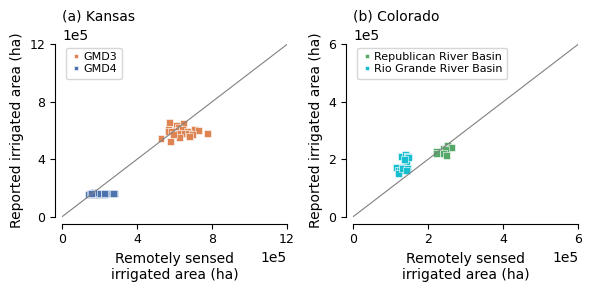

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

basin_colors = {
    'GMD4': '#4c72b0',
    'GMD3': '#dd8452',
    'Republican River Basin': '#55a868',
    'Rio Grande River Basin': '#17becf',
    # 'Diamond Valley': "#F21A0AE2",
}

fontsize = 10
legend_font = 8
marker_size = 25

fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs = axs.flatten()

# ── panel configs ──────────────────────────────────────────────────────────────
panels = [
    {
        'csv': PROJECT_ROOT / 'Model_run/basin_comparison_results/irr_hectares.csv',
        'filter': {'basin': ['GMD3', 'GMD4']},
        'rename': None,
        'x': 'RS_irrigated_hectares',
        'y': 'reported_irrigated_hectares',
        'xlabel': 'Remotely sensed\nirrigated area (ha)',
        'ylabel': 'Reported irrigated area (ha)',
        'lim': (0, 1200000),
        'sci': True, 'scilimits': (5, 5),
        'title': '(a) Kansas',
    },
    {
        'csv': PROJECT_ROOT / 'Model_run/basin_comparison_results/irr_hectares.csv',
        'filter': {'basin': ['RPB', 'SLV']},
        'rename': {'RPB': 'Republican River Basin', 'SLV': 'Rio Grande River Basin'},
        'x': 'RS_irrigated_hectares',
        'y': 'reported_irrigated_hectares',
        'xlabel': 'Remotely sensed\nirrigated area (ha)',
        'ylabel': 'Reported irrigated area (ha)',
        'lim': (0, 600000),
        'sci': True, 'scilimits': (5, 5),
        'title': '(b) Colorado',
    },

    # {
    #     'csv': PROJECT_ROOT / 'Model_run/basin_comparison_results/irr_hectares.csv',
    #     'filter': {'basin': ['DV']},
    #     'rename': {'DV': 'Diamond Valley'},
    #     'x': 'RS_irrigated_hectares',
    #     'y': 'reported_irrigated_hectares',
    #     'xlabel': 'Remotely sensed\nirrigated area (ha)',
    #     'ylabel': 'Reported irrigated area (ha)',
    #     'lim': (0, 15000),
    #     'sci': True, 'scilimits': (4, 4),
    #     'title': '(c) Nevada',
    # },
]

for ax, p in zip(axs, panels):
    df = pd.read_csv(p['csv'])
    df = df[df['basin'].isin(p['filter']['basin'])]
    if p['rename']:
        df['basin'] = df['basin'].map(p['rename'])

    sns.scatterplot(data=df, x=p['x'], y=p['y'], hue='basin',
                    palette=basin_colors, marker='s', s=marker_size, ax=ax)

    ax.plot([0, 1], [0, 1], 'gray', transform=ax.transAxes, lw=0.8)
    ax.set_xlim(p['lim'])
    ax.set_ylim(p['lim'])
    ax.set_xlabel(p['xlabel'], fontsize=fontsize)
    ax.set_ylabel(p['ylabel'], fontsize=fontsize)
    ax.set_title(p['title'], fontsize=fontsize, loc='left')
    ax.tick_params(labelsize=fontsize - 1)

    if 'ticks' in p:
        ax.set_xticks(p['ticks'])
        ax.set_yticks(p['ticks'])
    
    else:
        ax.set_xticks(np.linspace(p['lim'][0], p['lim'][1], 4))
        ax.set_yticks(np.linspace(p['lim'][0], p['lim'][1], 4))

    if p['sci']:
        ax.ticklabel_format(style='sci', scilimits=p['scilimits'])

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=legend_font, markerscale=0.7,
              frameon=True, handlelength=1, handletextpad=0.2,
              labelspacing=0.2, borderaxespad=0.3, loc='upper left')

sns.despine(offset=5, trim=True)
plt.tight_layout(pad=1.0)

save_path = PROJECT_ROOT / 'Model_run/plots/irr_hectares_all.jpg'
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()